=== SHOP SALES ANALYSIS ===
----------------------------------------
total orders: 15
total revenue: Rs. 1540
average order value: Rs. 102.67
----------------------------------------
revenue by product:
product
juice        540
chocolate    250
water        220
biscuits     210
chips        200
colddrink    120
Name: revenue, dtype: int64
----------------------------------------
revenue by category:
category
drinks    880
snacks    660
Name: revenue, dtype: int64
----------------------------------------
best performing city: indore
city wise revenue:
city
indore    450
mumbai    400
bhopal    350
delhi     340
Name: revenue, dtype: int64


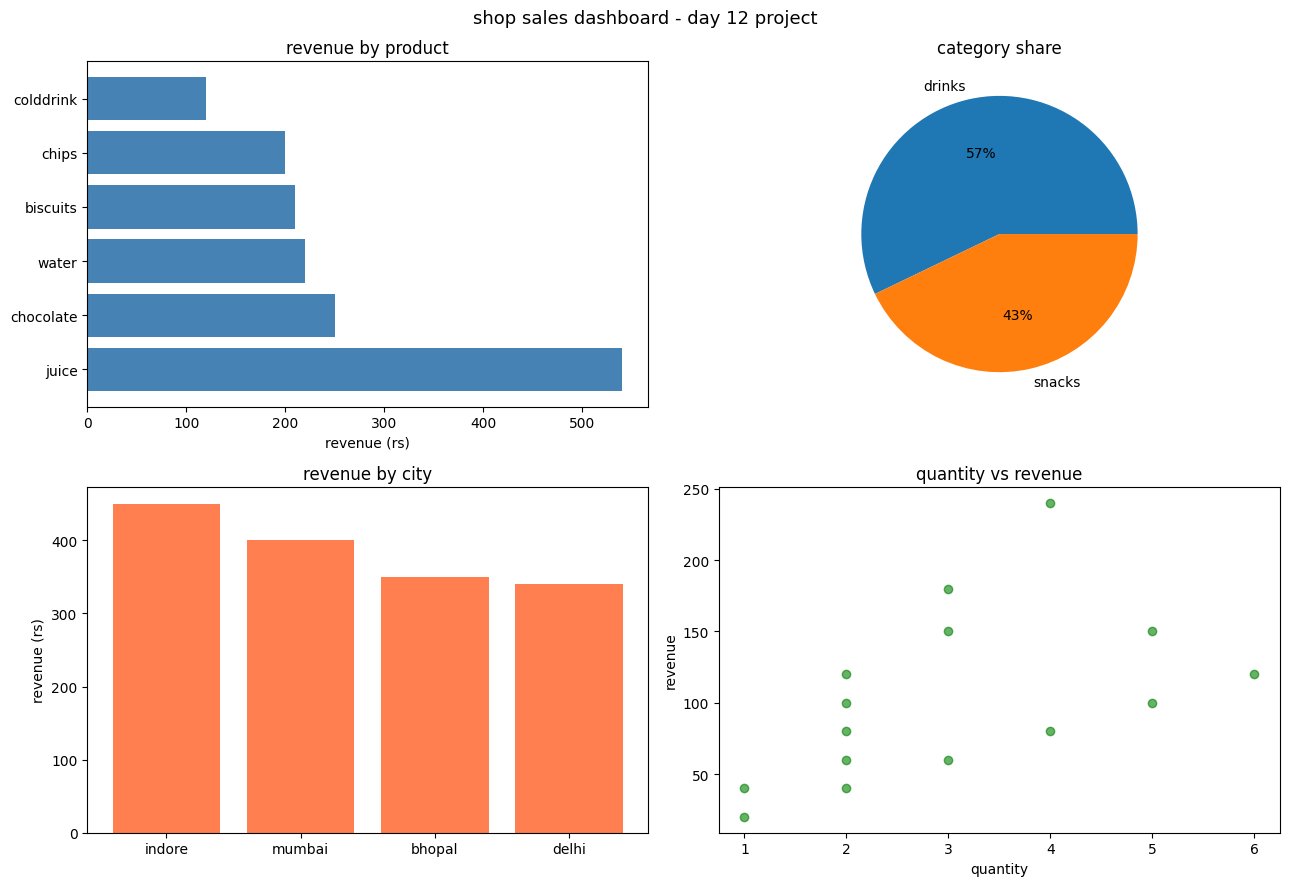

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "order_id": range(1, 16),
    "product": ["chips", "juice", "biscuits", "colddrink", "chocolate",
                "chips", "water", "juice", "biscuits", "chips",
                "chocolate", "colddrink", "water", "juice", "chips"],
    "category": ["snacks", "drinks", "snacks", "drinks", "snacks",
                 "snacks", "drinks", "drinks", "snacks", "snacks",
                 "snacks", "drinks", "drinks", "drinks", "snacks"],
    "quantity": [3, 2, 5, 1, 2, 4, 6, 3, 2, 1, 3, 2, 5, 4, 2],
    "price": [20, 60, 30, 40, 50, 20, 20, 60, 30, 20, 50, 40, 20, 60, 20],
    "city": ["indore", "bhopal", "indore", "delhi", "mumbai",
             "bhopal", "indore", "delhi", "mumbai", "indore",
             "bhopal", "delhi", "indore", "mumbai", "delhi"]
}

df = pd.DataFrame(data)

df["revenue"] = df["quantity"] * df["price"]

print("=== SHOP SALES ANALYSIS ===")
print("-" * 40)

print("total orders:", len(df))
print("total revenue: Rs.", df["revenue"].sum())
print("average order value: Rs.", round(df["revenue"].mean(), 2))

print("-" * 40)

product_rev = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
print("revenue by product:")
print(product_rev)

print("-" * 40)

cat_rev = df.groupby("category")["revenue"].sum()
print("revenue by category:")
print(cat_rev)

print("-" * 40)

city_rev = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
print("best performing city:", city_rev.index[0])
print("city wise revenue:")
print(city_rev)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].barh(product_rev.index, product_rev.values, color="steelblue")
axes[0, 0].set_title("revenue by product")
axes[0, 0].set_xlabel("revenue (rs)")

axes[0, 1].pie(cat_rev.values, labels=cat_rev.index, autopct="%1.0f%%")
axes[0, 1].set_title("category share")

axes[1, 0].bar(city_rev.index, city_rev.values, color="coral")
axes[1, 0].set_title("revenue by city")
axes[1, 0].set_ylabel("revenue (rs)")

axes[1, 1].scatter(df["quantity"], df["revenue"], color="green", alpha=0.6)
axes[1, 1].set_title("quantity vs revenue")
axes[1, 1].set_xlabel("quantity")
axes[1, 1].set_ylabel("revenue")

plt.suptitle("shop sales dashboard - day 12 project", fontsize=13)
plt.tight_layout()
plt.show()